# Explainability & Analysis

## Setup

In [1]:
import csv
import os
import pickle
import subprocess
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "grad-cam"])
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)

from config import BATCH_SIZE, SEED
from src.dataloader import get_dataloaders
from src.model import DissagreementPredictor
from src.utils import set_seed

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FIGURES_DIR = PROJECT_ROOT / "figures"
MANUAL_DIR = FIGURES_DIR / "manual_analysis"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MANUAL_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
CIFAR10_MEAN = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32)
CIFAR10_STD = np.array([0.2023, 0.1994, 0.2010], dtype=np.float32)

set_seed(SEED)
DEVICE

device(type='cpu')

In [2]:
def load_cifar_batch(batch_path):
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=r"dtype\(\): align should be passed as Python or NumPy boolean.*",
            category=np.exceptions.VisibleDeprecationWarning,
        )
        with open(batch_path, "rb") as f:
            batch = pickle.load(f, encoding="bytes")
    return batch


def resolve_checkpoint_path(model_path):
    model_path = Path(model_path)
    if model_path.exists():
        return model_path

    candidate_names = [
        model_path.name,
        model_path.name.replace("best_model_", "best_model _"),
        model_path.name.replace(" ", ""),
    ]
    for candidate_name in candidate_names:
        candidate_path = model_path.with_name(candidate_name)
        if candidate_path.exists():
            return candidate_path

    matches = sorted(model_path.parent.glob(f"*{model_path.stem.split('_')[-1]}*.pt"))
    if len(matches) == 1:
        return matches[0]

    raise FileNotFoundError(
        f"Could not find checkpoint for {model_path.name}. Available files: "
        f"{sorted(path.name for path in model_path.parent.glob('*'))}"
    )


def compute_entropy(distributions, eps=1e-8):
    distributions = np.clip(distributions, eps, 1.0)
    return -np.sum(distributions * np.log2(distributions), axis=1)


def collect_predictions(model, data_loader):
    all_preds = []
    all_true = []
    model.eval()
    with torch.no_grad():
        for imgs, targets in data_loader:
            preds = model(imgs.to(DEVICE))
            all_preds.append(preds.cpu().numpy())
            all_true.append(targets.numpy())
    return np.concatenate(all_preds, axis=0), np.concatenate(all_true, axis=0)


def flat_image_to_rgb(flat_image):
    image = flat_image.reshape(3, 32, 32).transpose(1, 2, 0).astype(np.float32) / 255.0
    return np.clip(image, 0.0, 1.0)


def get_target_layer(model):
    try:
        return model.backbone[-1][-1]
    except Exception:
        return model.backbone[-2][-1]


batch = load_cifar_batch(PROJECT_ROOT / "data/raw/cifar-10-batches-py/test_batch")
images = batch[b"data"]
probs = np.load(PROJECT_ROOT / "data/raw/cifar10h-probs.npy")
test_idx = np.load(PROJECT_ROOT / "data/processed/test_idx.npy")

_, _, test_loader = get_dataloaders(images, probs, batch_size=BATCH_SIZE)
test_images_raw = images[test_idx]

model = DissagreementPredictor().to(DEVICE)
checkpoint_path = resolve_checkpoint_path(CHECKPOINTS_DIR / "best_model_kl.pt")
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
model.eval()

all_preds, all_true = collect_predictions(model, test_loader)
true_ent = compute_entropy(all_true)
pred_ent = compute_entropy(all_preds)

all_preds.shape, all_true.shape

((2000, 10), (2000, 10))

## Grad-CAM Analysis

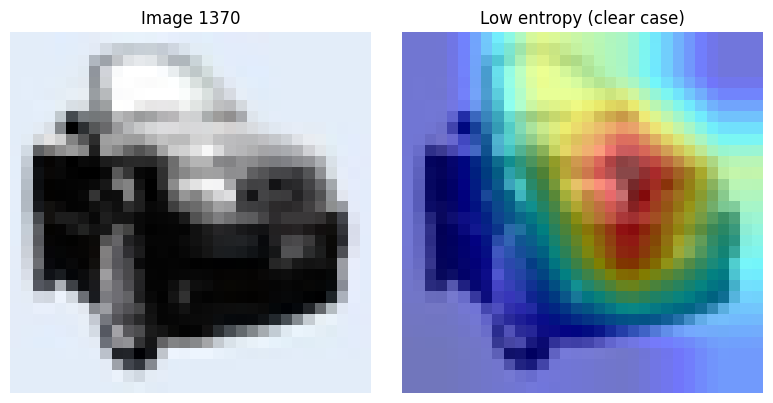

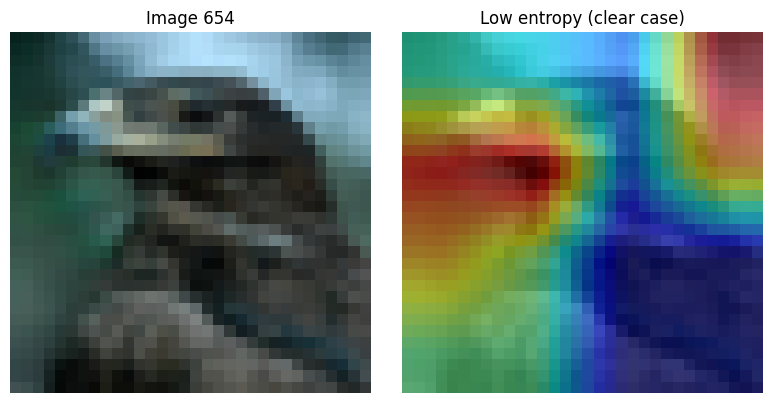

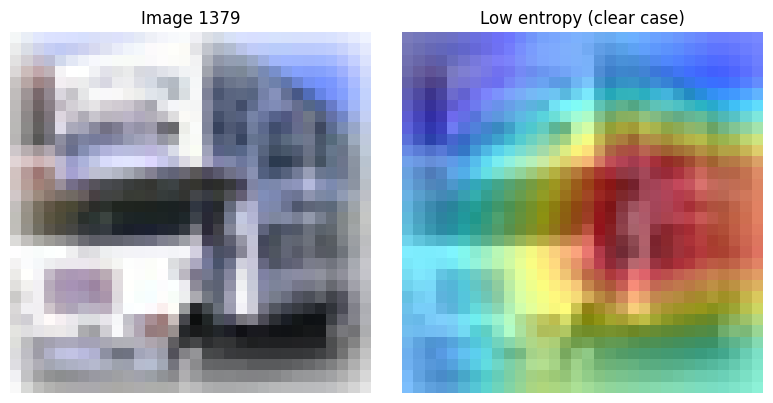

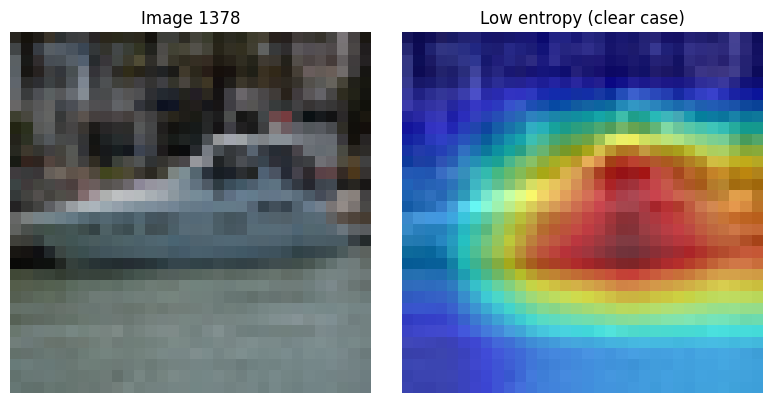

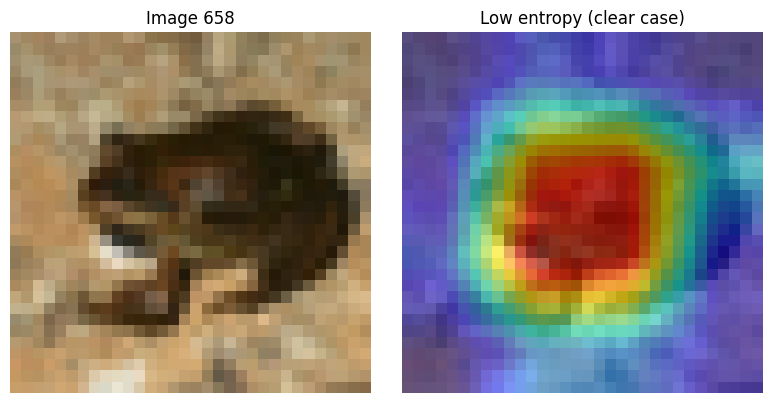

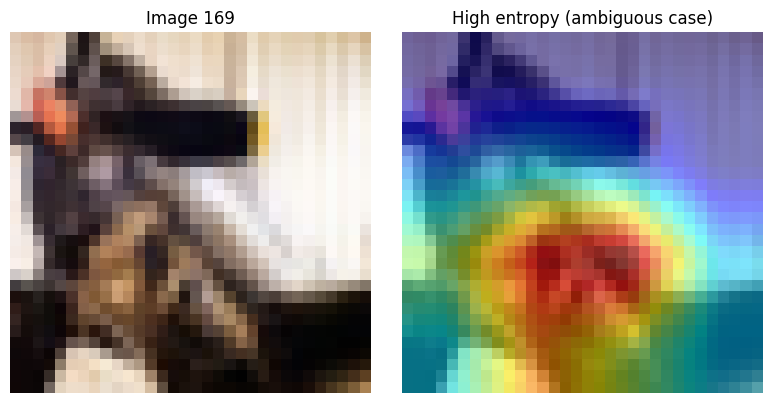

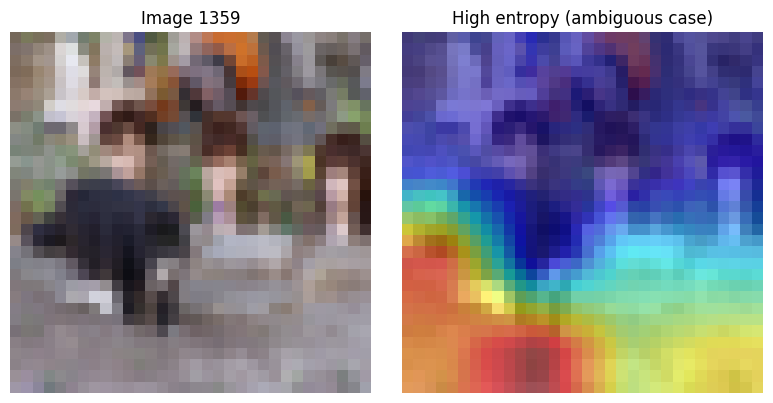

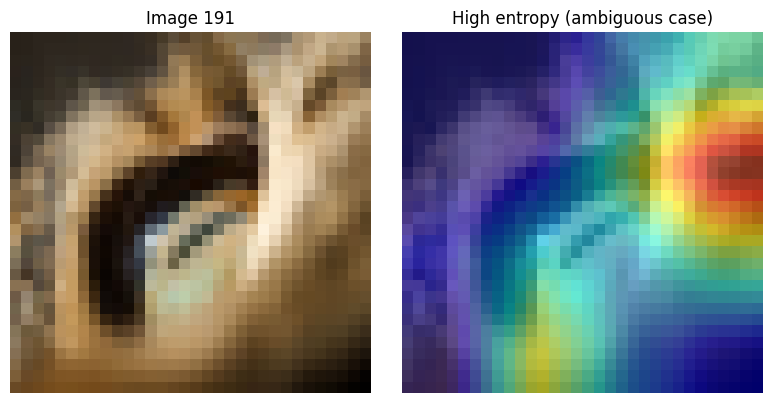

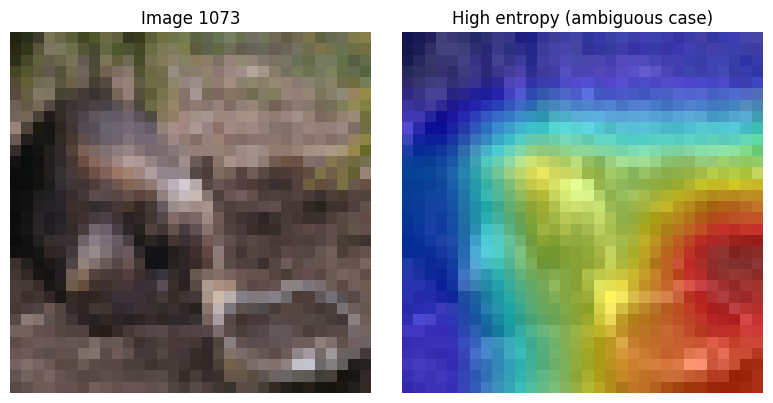

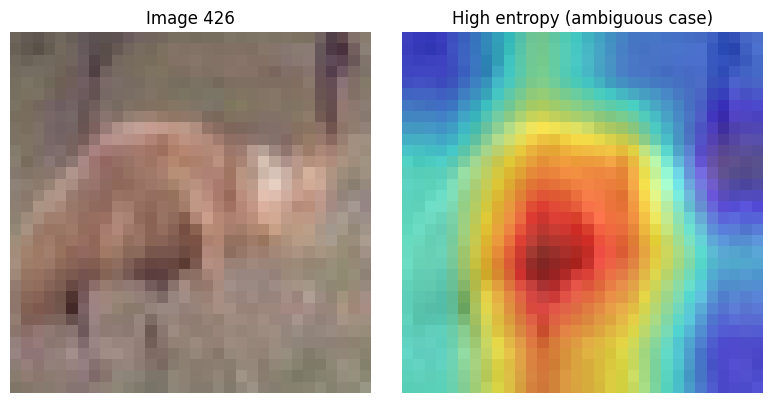

In [3]:
target_layer = get_target_layer(model)
low_entropy_indices = np.argsort(true_ent)[:5]
high_entropy_indices = np.argsort(true_ent)[-5:][::-1]


def save_gradcam_grid(indices, prefix, title_text):
    cam = GradCAM(model=model, target_layers=[target_layer])
    for rank, idx in enumerate(indices):
        input_tensor = test_loader.dataset[idx][0].unsqueeze(0).to(DEVICE)
        rgb_image = flat_image_to_rgb(test_images_raw[idx])
        target_class = int(np.argmax(all_preds[idx]))
        grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(target_class)])[0]
        overlay = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(rgb_image)
        axes[0].set_title(f"Image {idx}")
        axes[0].axis("off")
        axes[1].imshow(overlay)
        axes[1].set_title(title_text)
        axes[1].axis("off")
        plt.tight_layout()
        output_path = FIGURES_DIR / f"{prefix}_{rank:02d}.png"
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)


save_gradcam_grid(low_entropy_indices, "gradcam_low_entropy", "Low entropy (clear case)")
save_gradcam_grid(high_entropy_indices, "gradcam_high_entropy", "High entropy (ambiguous case)")

## Failure Case Analysis

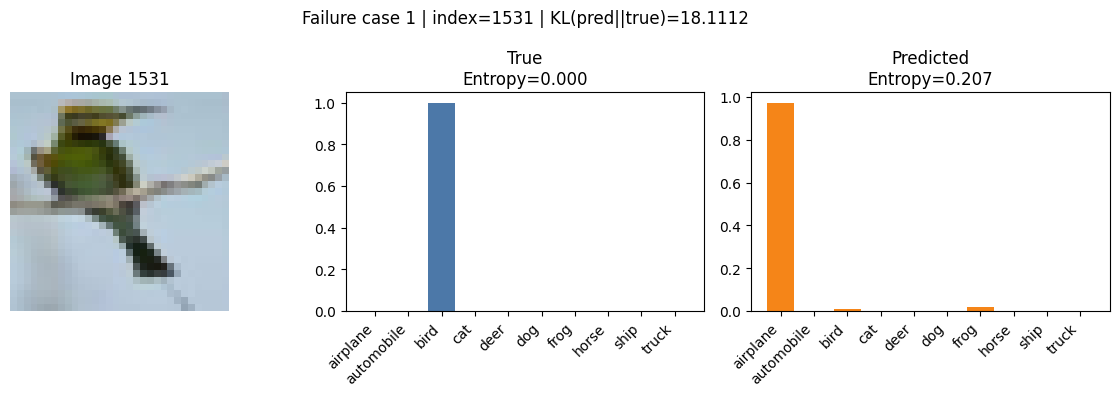

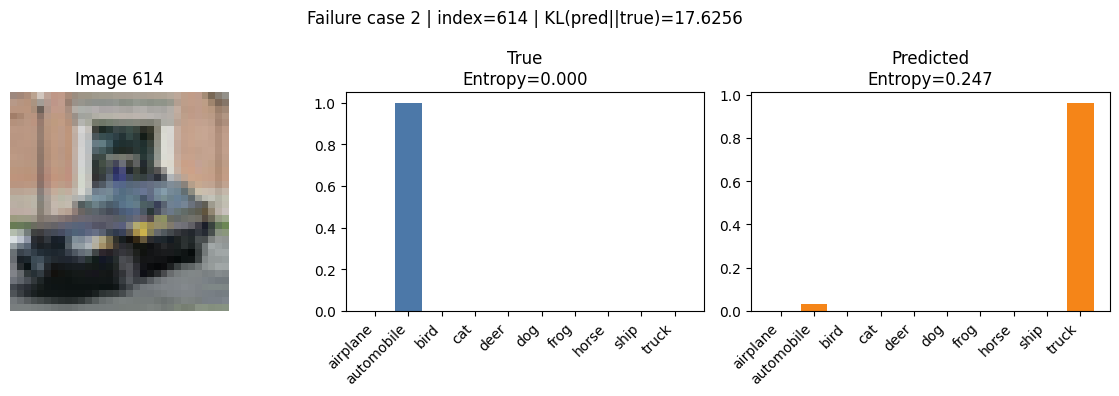

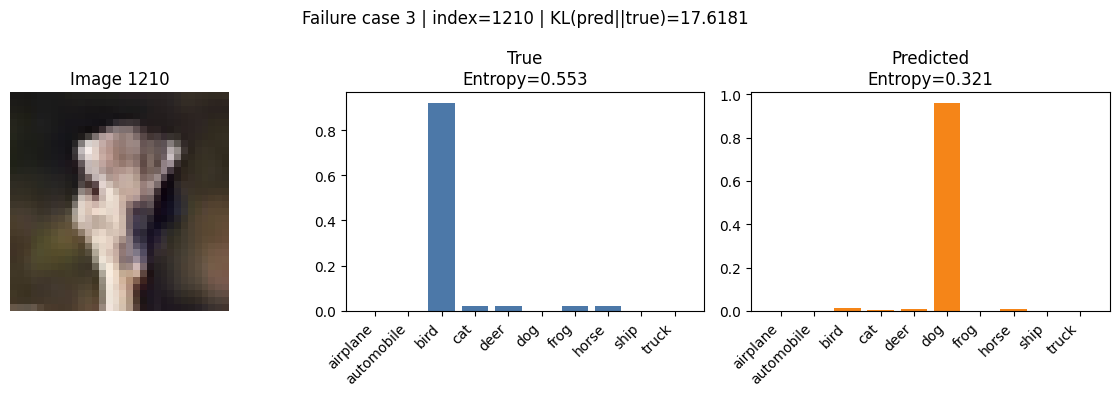

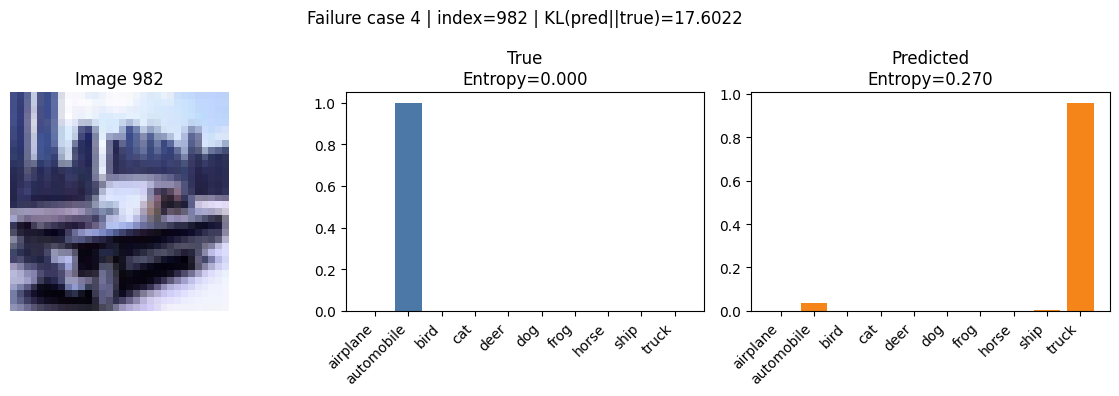

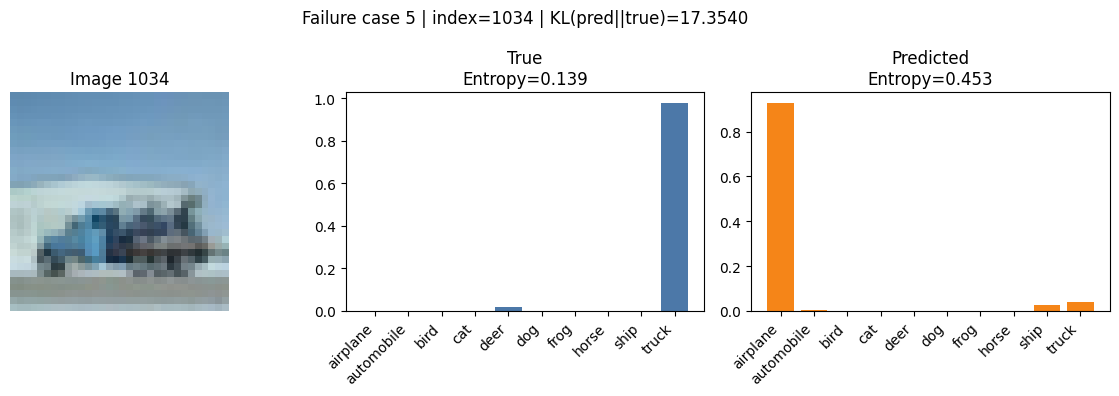

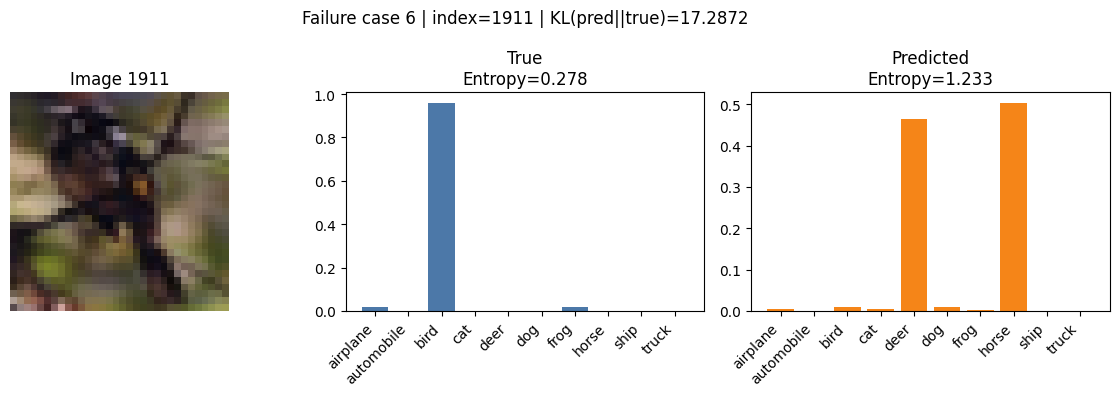

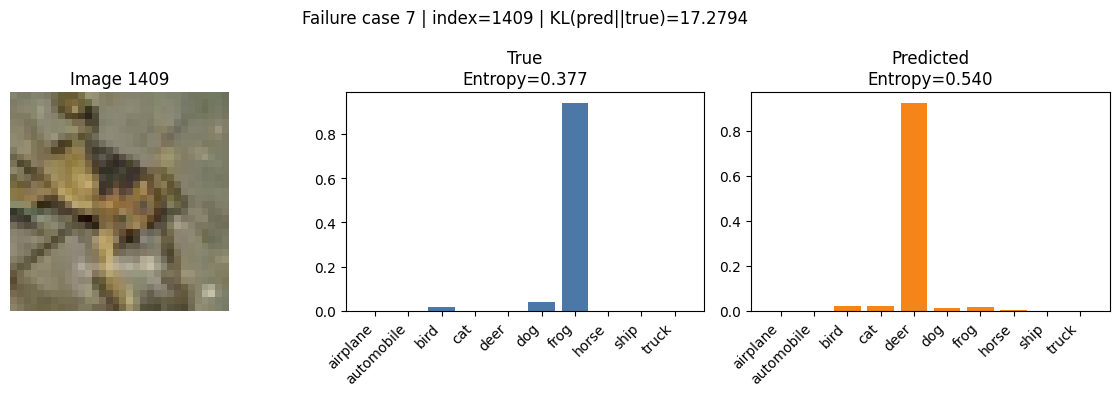

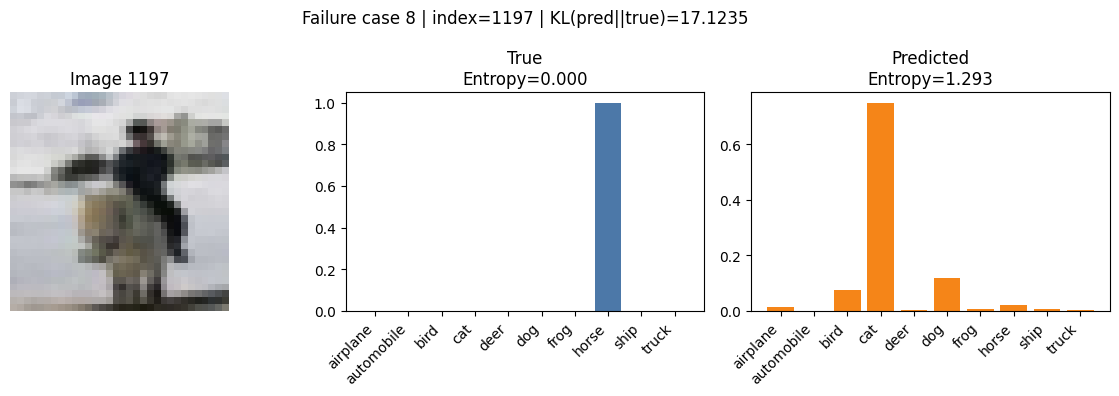

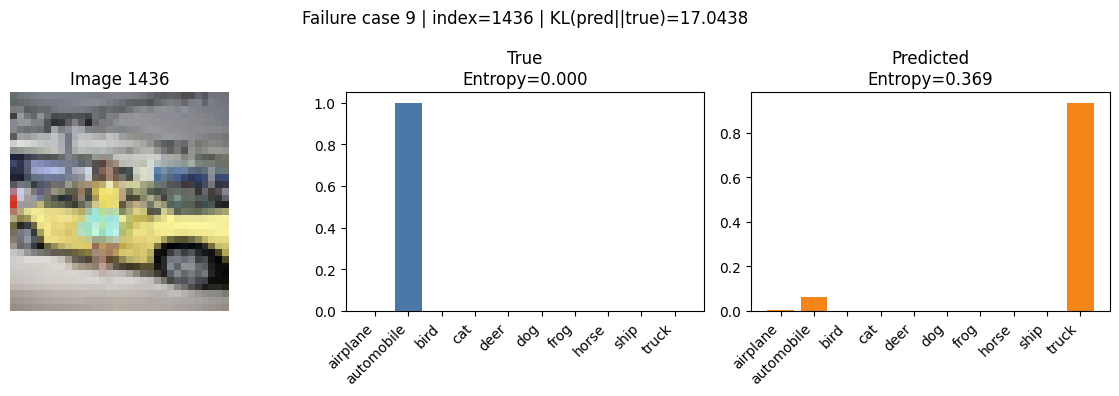

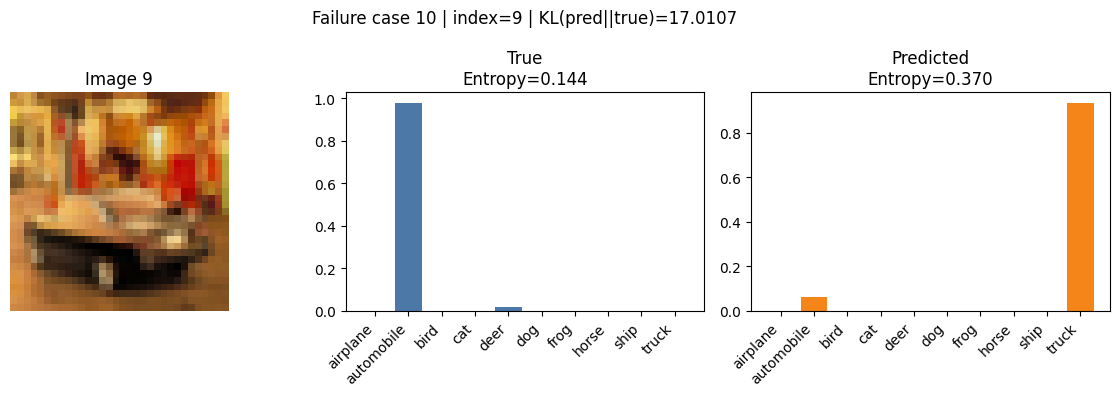

In [4]:
def kl_pred_true(preds, true, eps=1e-8):
    preds = np.clip(preds, eps, 1.0)
    true = np.clip(true, eps, 1.0)
    return np.sum(preds * (np.log(preds) - np.log(true)), axis=1)


per_image_kl = kl_pred_true(all_preds, all_true)
worst_indices = np.argsort(per_image_kl)[-10:][::-1]

for rank, idx in enumerate(worst_indices):
    rgb_image = flat_image_to_rgb(test_images_raw[idx])
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(rgb_image)
    axes[0].set_title(f"Image {idx}")
    axes[0].axis("off")

    axes[1].bar(np.arange(10), all_true[idx], color="#4C78A8")
    axes[1].set_title(f"True\nEntropy={true_ent[idx]:.3f}")
    axes[1].set_xticks(np.arange(10))
    axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha="right")

    axes[2].bar(np.arange(10), all_preds[idx], color="#F58518")
    axes[2].set_title(f"Predicted\nEntropy={pred_ent[idx]:.3f}")
    axes[2].set_xticks(np.arange(10))
    axes[2].set_xticklabels(CLASS_NAMES, rotation=45, ha="right")

    fig.suptitle(f"Failure case {rank + 1} | index={idx} | KL(pred||true)={per_image_kl[idx]:.4f}")
    plt.tight_layout()
    output_path = FIGURES_DIR / f"failure_case_{rank:02d}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Manual Disagreement Analysis Support

In [5]:
manual_indices = np.argsort(true_ent)[-30:][::-1]
csv_path = FIGURES_DIR / "manual_analysis_labels.csv"

for idx in manual_indices:
    rgb_image = flat_image_to_rgb(test_images_raw[idx])
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(rgb_image)
    ax.set_title(f"Index {idx} | Entropy={true_ent[idx]:.3f}")
    ax.axis("off")
    plt.tight_layout()
    output_path = MANUAL_DIR / f"image_{idx:04d}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

if not csv_path.exists():
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["index", "category"])
        for idx in manual_indices:
            writer.writerow([int(idx), ""])

manual_indices[:10], csv_path

(array([ 169, 1359,  191, 1073,  426, 1159, 1203, 1211,  424,   93]),
 PosixPath('/media/introverted-duck/New Volume/codes/devudaaaaa/human_annotator_disagreement_predictor/figures/manual_analysis_labels.csv'))

## Summary Visualization

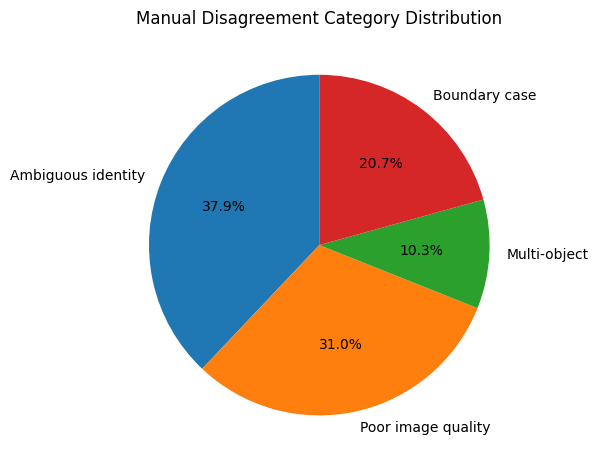

In [8]:
categories = [
    "Ambiguous identity",
    "Poor image quality",
    "Multi-object",
    "Boundary case",
    "Other",
]

label_counts = {category: 0 for category in categories}
with open(csv_path, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        category = row["category"].strip()
        if category in label_counts:
            label_counts[category] += 1

nonzero = {key: value for key, value in label_counts.items() if value > 0}
fig, ax = plt.subplots(figsize=(6, 6))
if nonzero:
    ax.pie(nonzero.values(), labels=nonzero.keys(), autopct="%1.1f%%", startangle=90)
    ax.set_title("Manual Disagreement Category Distribution")
else:
    ax.text(0.5, 0.5, "Fill figures/manual_analysis_labels.csv\nand rerun this cell", ha="center", va="center", fontsize=12)
    ax.set_title("Manual Disagreement Category Distribution")
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "disagreement_pie_chart.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)